In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import time
torch.set_default_dtype(torch.float64)

def set_BCs(T):
    T[0]  = T[1]
    T[-1] = T[-2]**2 / max(T[-3].item(), 1e-40)  # .item() needed for cuda


In [3]:
def solve_two_layer_FTCS(k1, k2, z_dis, Pda, Lz, nz, tf, Delta_d, device):
    # spatial grid
    dz = Lz / nz
    z  = torch.arange(-0.5, nz + 1, device=device) * dz   # (nz+2,)
    zh = 0.5 * (z[:-1] + z[1:])                           # (nz+1,)

    # interface setup
    m = torch.searchsorted(z, z_dis, right=True).item() - 1
    print(f'Interface alignment error: {z[m].item() + 0.5*dz - z_dis:.2e}')
    k_interface = 2 * k1 * k2 / (k1 + k2)
    kh = torch.where(z[:-1] < z_dis,
                     torch.tensor(k1, device=device),
                     torch.tensor(k2, device=device))
    kh[m] = k_interface

    # Outputs for the 2D U(z,t)
    dt_stab = 0.5 * (dz**2) / max(k1, k2)
    n_sub_t = int(np.ceil(Delta_d / dt_stab))
    dt      = Delta_d / n_sub_t
    print(f'n_sub_t={n_sub_t}, dt={dt:.4e}')

    source = Pda * torch.exp(-z[1:-1])

    T      = torch.zeros(nz + 2, device=device)
    U_list = []
    t_list = []

    for step in range(n_sub_t):
        set_BCs(T)
        Jh = -kh * (T[1:] - T[:-1]) / dz
        T[1:-1] = T[1:-1] + dt / dz * (Jh[:-1] - Jh[1:]) + dt * source
        U_list.append(T.clone())
        t_list.append((step + 1) * dt)

    t_out = torch.tensor(t_list, device=device)
    U     = torch.stack(U_list, dim=1)    # (nz+2, n_sub_t)
    return z, zh, t_out, U 


## Run the solver

In [4]:
%run func_defs.ipynb
device = 'cuda'
k1 = 1.0; k2 = 4; z_dis = 1; Pda = 1.0; tf = 2.0
Lz = 10.0; nz_unit = 10; nz = int(Lz) * nz_unit

Delta_d = 1.0 / 4.0   # controls n_sub_t ≈ nz

z, zh, t_out, U = solve_two_layer_FTCS(k1, k2, z_dis, Pda, Lz, nz, tf, Delta_d, device)
print(f'U shape: {U.shape}')   # (nz+2, n_sub_t) — roughly square

out_file = f'./data/2layer_k1{k1}_k2{k2}_nz{nz}.pt'

Interface alignment error: 0.00e+00
n_sub_t=200, dt=1.2500e-03
U shape: torch.Size([102, 200])


In [5]:
# Prep to change to s and tau 
zt_grid = torch.cartesian_prod(z, t_out)
zz = zt_grid[:, 0]; tt = zt_grid[:, 1]

stau = torch.column_stack(z_t_to_s_tau(zz, tt))
W = W_stau(stau).reshape(-1,1)


kratio = torch.ones(len(stau[:,1]),device=device)*(k1/k2)
z_disv = torch.ones(len(stau[:,1]),device=device)*z_dis
#kratio = kratio.reshape(len(stau[:,1]),1)
#z_disv = z_disv.reshape(len(stau[:,1]),1)


In [6]:
train = torch.stack([stau[:,0],stau[:,1], kratio, z_disv], dim=-1)

In [24]:
data_to_save = {
        't': tt,
        'z': zz,
        'kratio':  kratio,
        'zdis': z_disv,
        'stau': stau,
        'W': W
    }
torch.save(data_to_save, out_file)
print(f'Data saved in {out_file}')

Data saved in ./data/2layer_k11.0_k24_nz100.pt


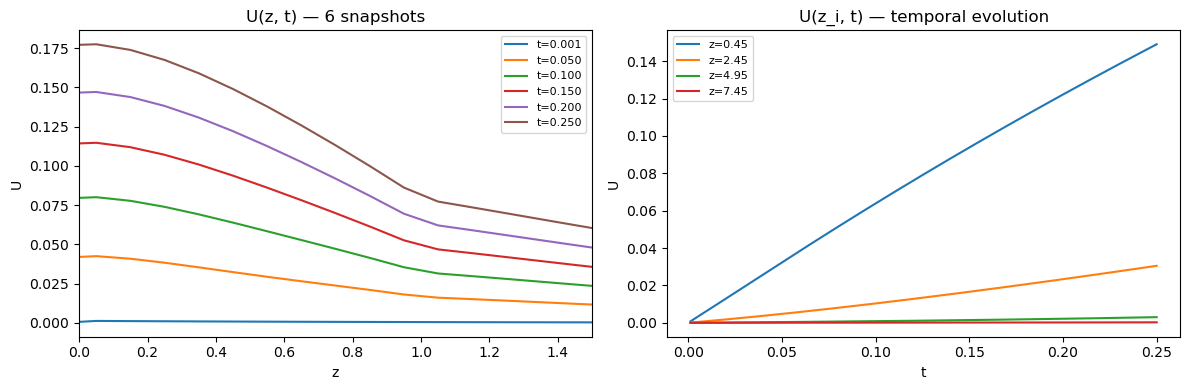

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

z_cpu = z.cpu(); U_cpu = U.cpu(); t_cpu = t_out.cpu()

# U(z): 6 evenly spaced snapshots
ax = axes[0]
idx = torch.linspace(0, U_cpu.shape[1]-1, 6).long()
for i in idx:
    ax.plot(z_cpu.numpy(), U_cpu[:, i].numpy(), label=f't={t_cpu[i]:.3f}')
ax.set_xlabel('z'); ax.set_ylabel('U');ax.set_xlim([0,1.5])
ax.set_title('U(z, t) — 6 snapshots')
ax.legend(fontsize=8)

# U(t) at 4 z locations
ax = axes[1]
for iz in [5, nz//4, nz//2, 3*nz//4]:
    ax.plot(t_cpu.numpy(), U_cpu[iz, :].numpy(), label=f'z={z_cpu[iz]:.2f}')
ax.set_xlabel('t'); ax.set_ylabel('U')
ax.set_title('U(z_i, t) — temporal evolution')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
